# Telco Customer Churn — Data Preparation, Cleaning, EDA & Wrangling

**Project goal:** prepare the Telco Customer Churn dataset for a Machine Learning classification model.

Each row represents one customer. The target variable is:

- `churn`: whether the customer left the company (`Yes`) or stayed (`No`).

This notebook covers **Day 2: Data Preparation**:

1. Data loading and first inspection  
2. Cleaning  
3. Column renaming using snake_case  
4. Missing values and duplicates  
5. Data type correction  
6. Split between categorical and numerical features  
7. Exploratory Data Analysis  
8. Outlier and distribution analysis  
9. Feature engineering / wrangling  
10. Export of a clean dataset ready for Machine Learning

## 0. Import libraries and configuration

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 1. Load the dataset

In [13]:
# Path to the raw dataset
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. First data inspection

Before cleaning, we check the basic structure of the dataset.

In [14]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 7043
Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nul

In [15]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Rename columns to PE8 / snake_case

The original column names use a mix of camelCase and PascalCase.  
For cleaner Python code, we convert all names to `lower_case_with_underscores`.

In [17]:
import re

def to_snake_case(column_name: str) -> str:
    """Convert column names to snake_case."""
    column_name = re.sub(r"(?<=[a-z0-9])(?=[A-Z])", "_", column_name)
    column_name = column_name.replace(" ", "_").replace("-", "_")
    column_name = re.sub(r"[^a-zA-Z0-9_]", "", column_name)
    column_name = re.sub(r"_+", "_", column_name)
    return column_name.lower().strip("_")

df.columns = [to_snake_case(col) for col in df.columns]

df.columns.tolist()

['customer_id',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn']

## 4. Check missing values

At first glance, the dataset may look like it has no null values.  
However, `total_charges` is stored as text and may contain blank spaces that represent missing values.

In [18]:
df.isna().sum().sort_values(ascending=False)

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

### 4.1 Fix `total_charges`

`total_charges` should be numeric, but it is currently stored as an object.  
We convert it to numeric and force invalid values to become `NaN`.

In [19]:
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

df[["tenure", "monthly_charges", "total_charges"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure           7043 non-null   int64  
 1   monthly_charges  7043 non-null   float64
 2   total_charges    7032 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


In [20]:
df.isna().sum().sort_values(ascending=False)

total_charges        11
gender                0
senior_citizen        0
partner               0
customer_id           0
dependents            0
tenure                0
multiple_lines        0
phone_service         0
online_security       0
online_backup         0
device_protection     0
internet_service      0
tech_support          0
streaming_tv          0
contract              0
streaming_movies      0
paperless_billing     0
payment_method        0
monthly_charges       0
churn                 0
dtype: int64

### 4.2 Investigate rows with missing `total_charges`

These rows usually correspond to customers with `tenure = 0`, meaning they are new customers and have not accumulated charges yet.

In [21]:
df[df["total_charges"].isna()]

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


### 4.3 Handle missing values

Because the missing values in `total_charges` are linked to `tenure = 0`, we can reasonably replace them with `0`.

This keeps the customers in the dataset and preserves the business logic.

In [22]:
df["total_charges"] = df["total_charges"].fillna(0)

df.isna().sum().sum()

np.int64(0)

## 5. Check duplicates

In [23]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customer IDs: {df['customer_id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate customer IDs: 0


## 6. Check unique values

This helps us understand categorical variables and detect values that may need to be combined or simplified.

In [24]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    if df[col].nunique() <= 20:
        print(df[col].unique())


--- customer_id ---
Unique values: 7043

--- gender ---
Unique values: 2
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

--- senior_citizen ---
Unique values: 2
[0 1]

--- partner ---
Unique values: 2
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

--- dependents ---
Unique values: 2
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

--- tenure ---
Unique values: 73

--- phone_service ---
Unique values: 2
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

--- multiple_lines ---
Unique values: 3
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

--- internet_service ---
Unique values: 3
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

--- online_security ---
Unique values: 3
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

--- online_backup ---
Unique values: 3
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

--- device_protection ---
Unique values: 

## 7. Split columns into categorical and numerical

We separate categorical and numerical variables because they need different preprocessing techniques before modeling.

In [25]:
target = "churn"
id_column = "customer_id"

categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove ID and target from feature lists
categorical_cols = [col for col in categorical_cols if col not in [id_column, target]]
numerical_cols = [col for col in numerical_cols if col not in [target]]

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

Numerical columns:
['senior_citizen', 'tenure', 'monthly_charges', 'total_charges']


C:\Users\estef\AppData\Local\Temp\ipykernel_20788\1996393165.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


## 8. EDA — target distribution

We first check whether the target variable is balanced or imbalanced.

,count,percentage
churn,,
No,5174,73.46
Yes,1869,26.54


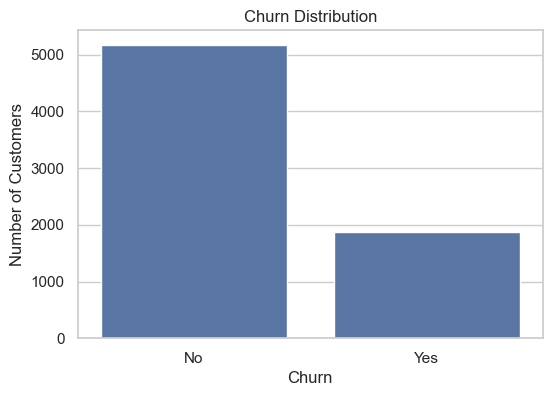

In [26]:
churn_counts = df["churn"].value_counts()
churn_percentage = df["churn"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_percentage.round(2)
}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

**Business note:** If churn is imbalanced, accuracy alone may be misleading.  
For this type of problem, `recall`, `precision`, `F1-score`, and `ROC-AUC` will be important during modeling.

## 9. EDA — plot categorical columns

The following charts show how customers are distributed across categorical variables and how churn behaves within each group.

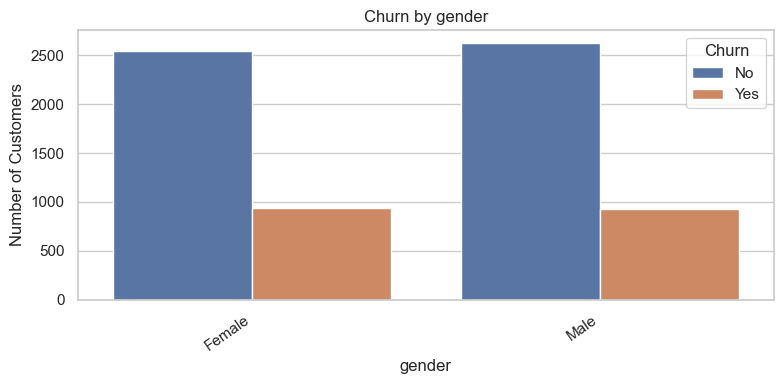

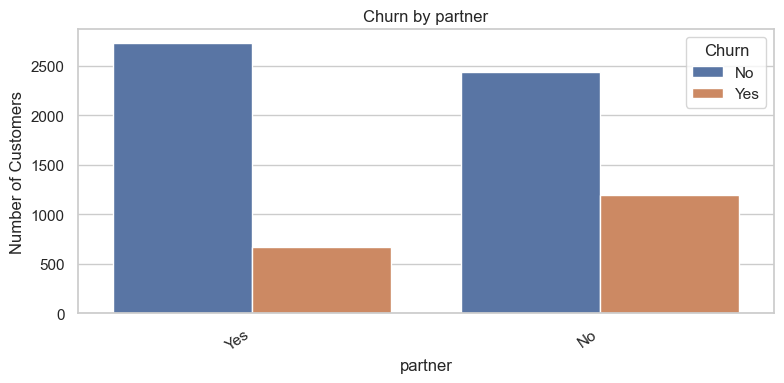

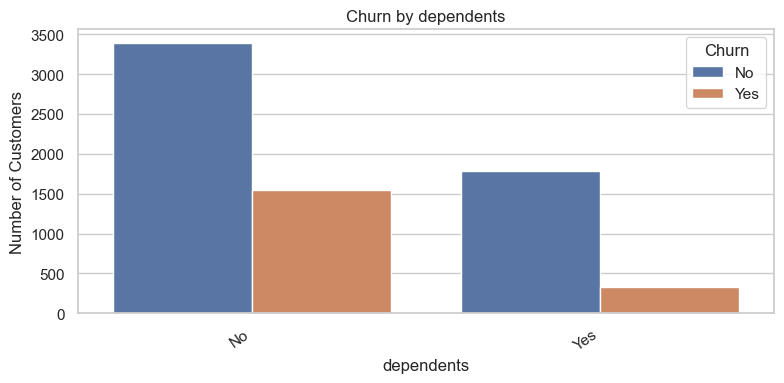

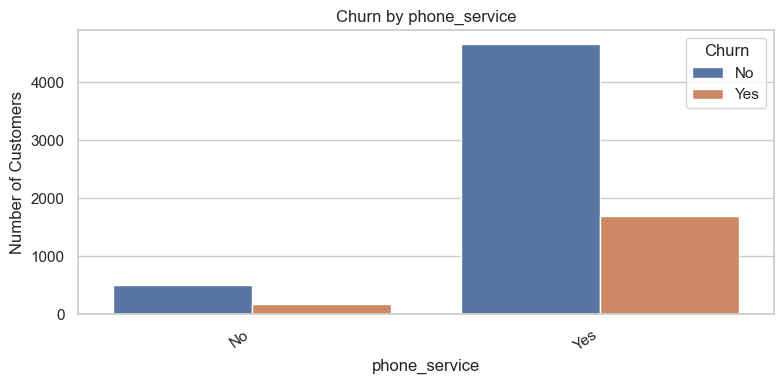

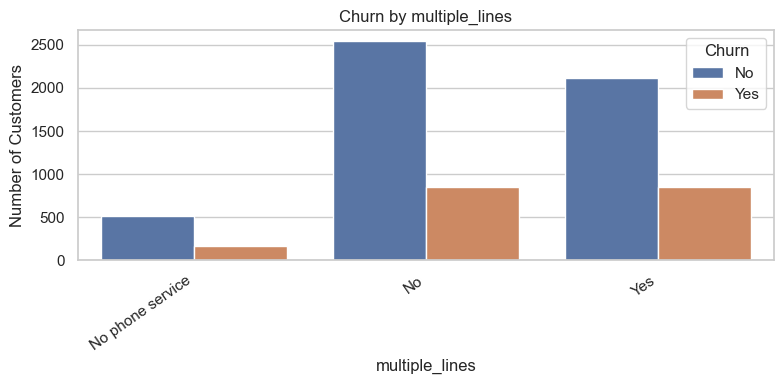

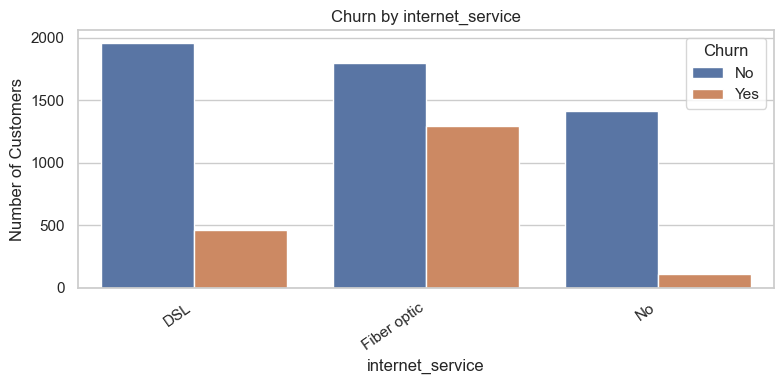

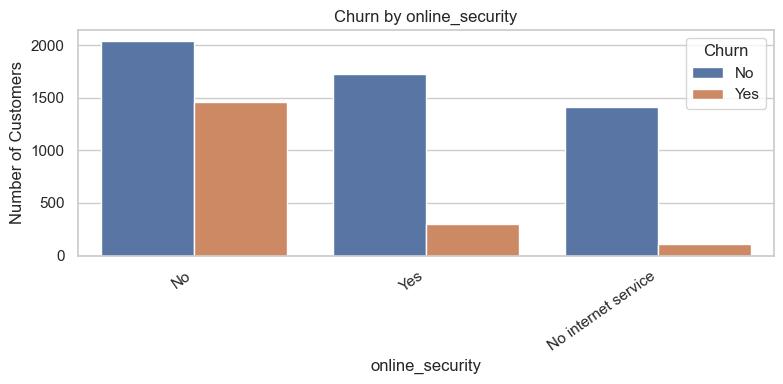

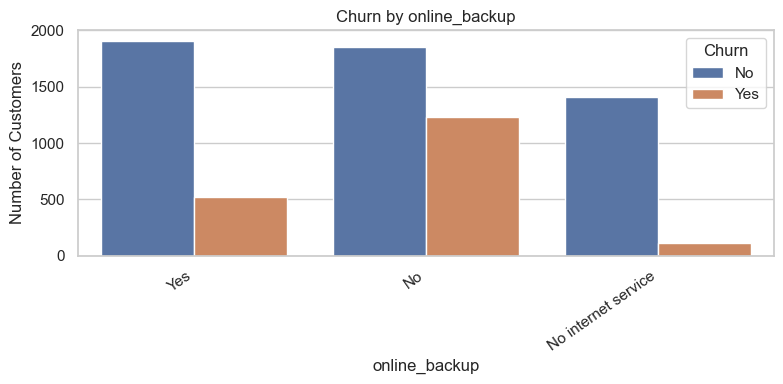

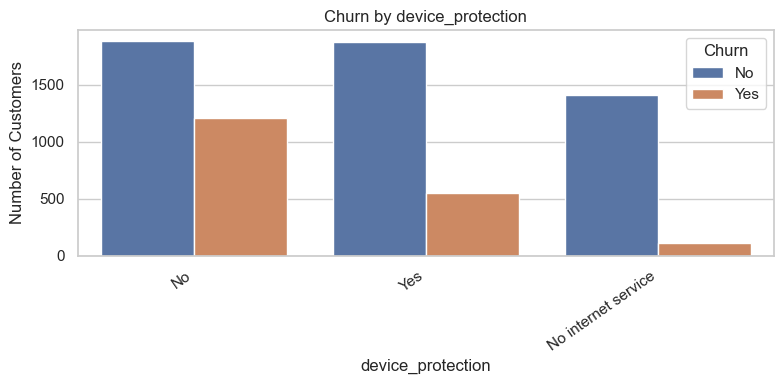

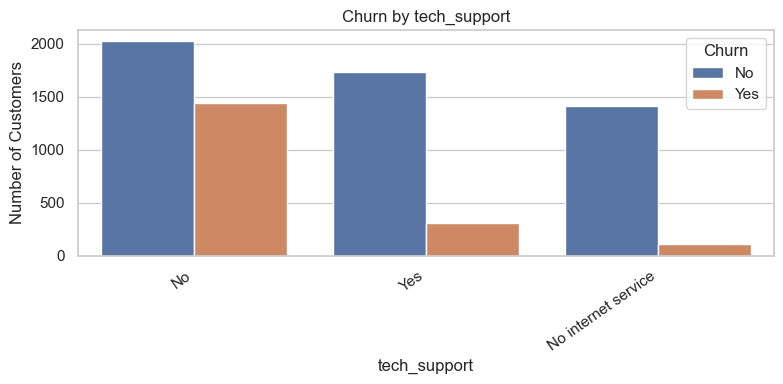

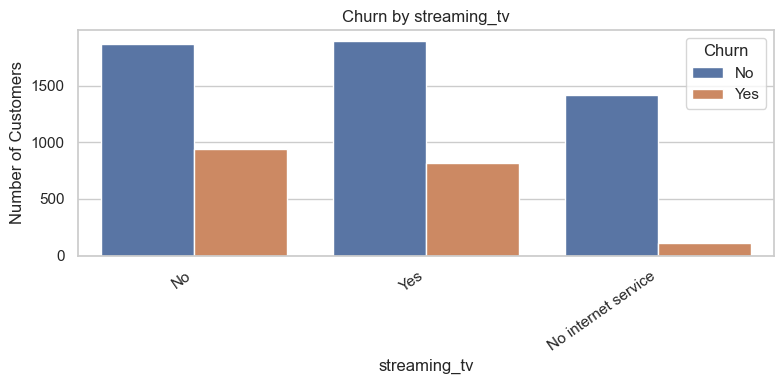

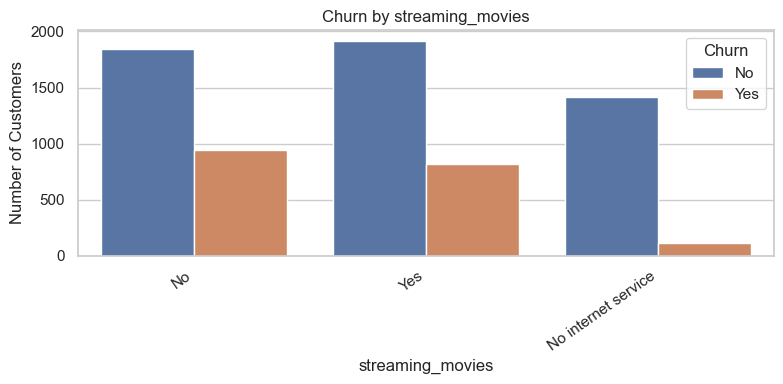

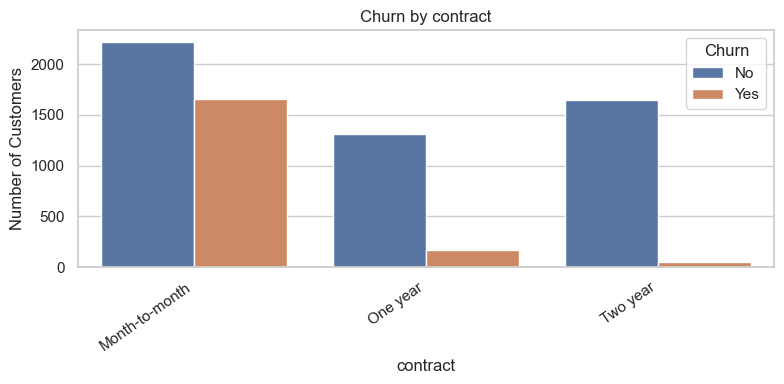

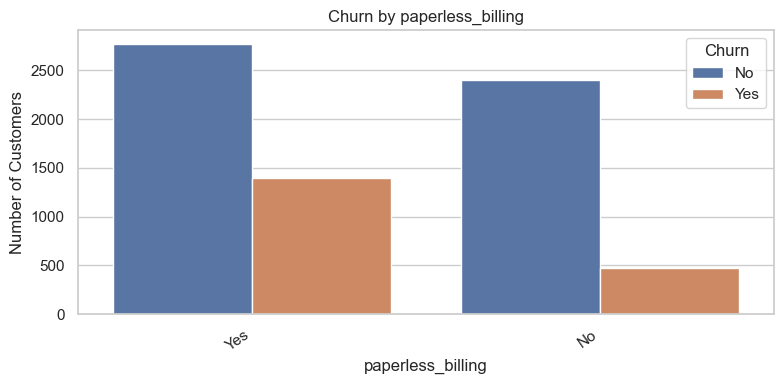

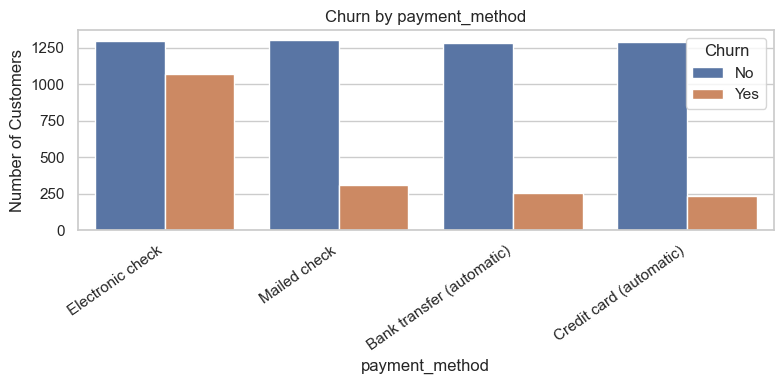

In [27]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="churn")
    plt.title(f"Churn by {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=35, ha="right")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

## 10. EDA — numerical distributions

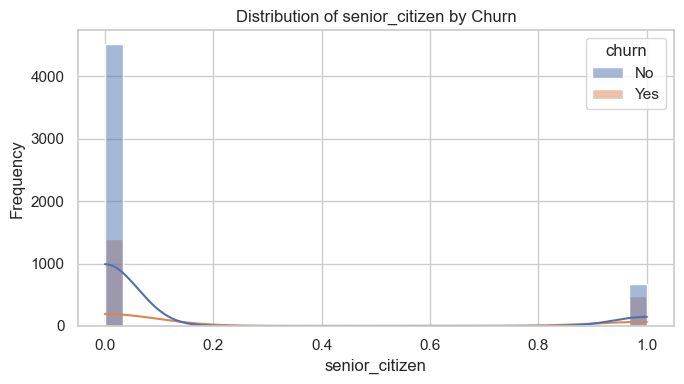

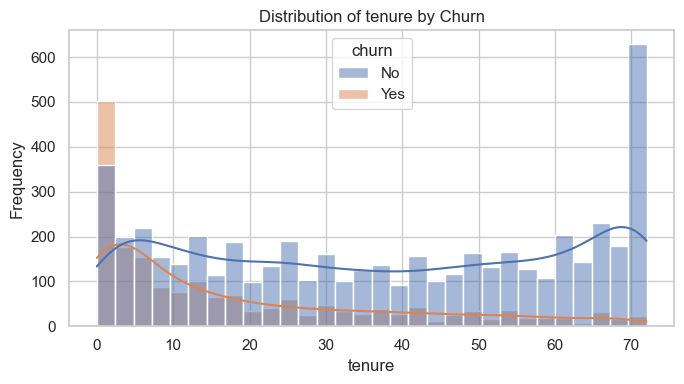

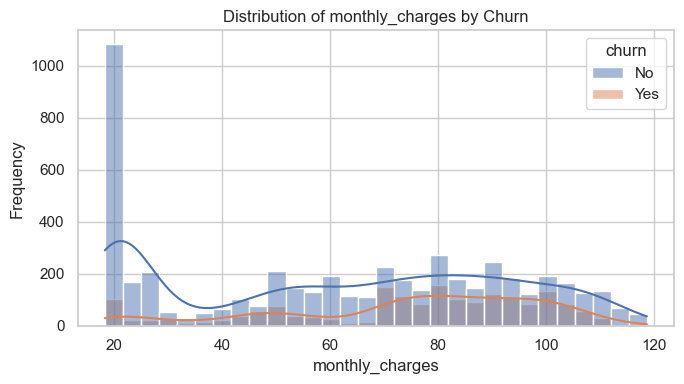

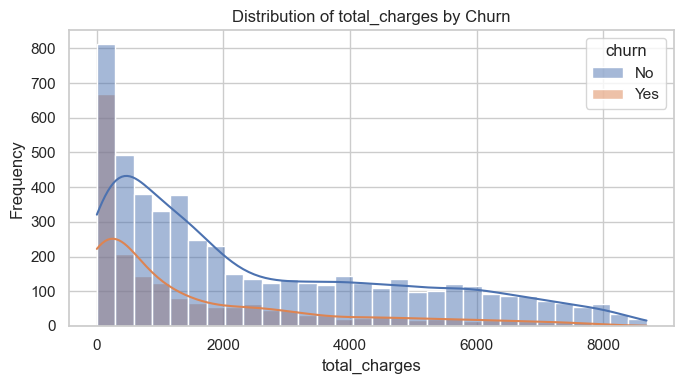

In [28]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="churn", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Churn")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 11. Check outliers in numerical columns

We use boxplots to visually inspect potential outliers.

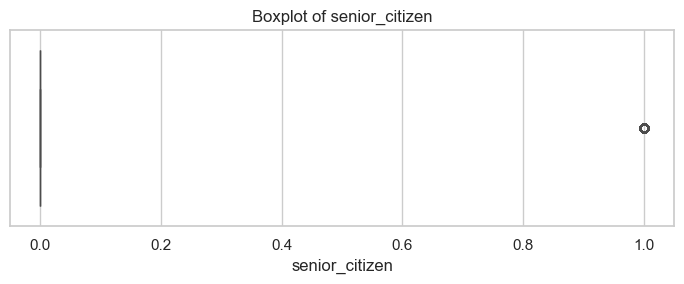

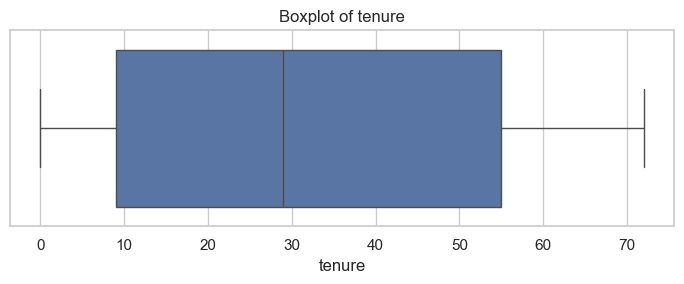

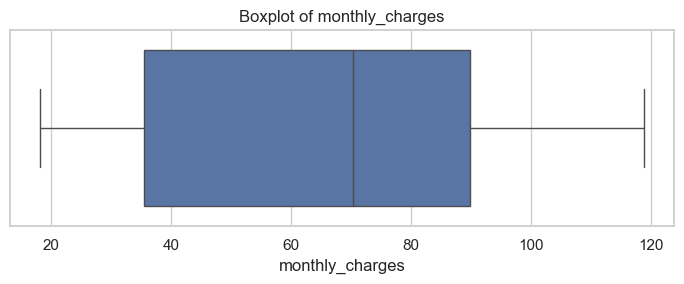

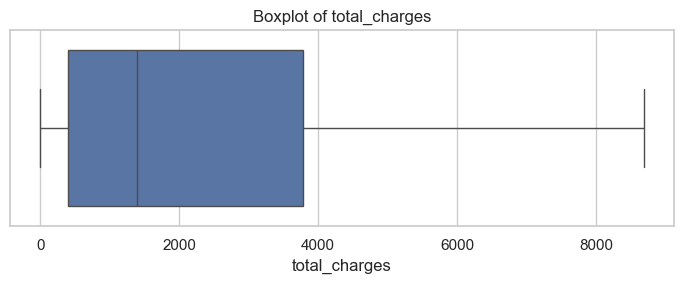

In [29]:
for col in numerical_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### 11.1 IQR outlier summary

This does not automatically mean we should remove outliers.  
In business datasets, extreme values can be valid customer behavior.

In [30]:
def iqr_outlier_summary(dataframe, columns):
    summary = []

    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]

        summary.append({
            "column": col,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outliers.shape[0],
            "outlier_percentage": round(outliers.shape[0] / dataframe.shape[0] * 100, 2)
        })

    return pd.DataFrame(summary)

iqr_outlier_summary(df, numerical_cols)

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,senior_citizen,0.000,0.000,1142,16.21
1,tenure,-60.000,124.000,0,0.00
2,monthly_charges,-46.025,171.375,0,0.00
3,total_charges,-4683.525,8868.675,0,0.00


## 12. Correlation between numerical variables

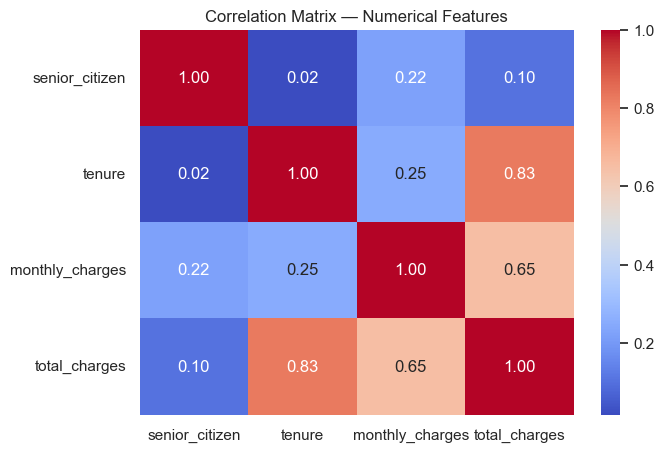

In [31]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Numerical Features")
plt.show()

## 13. Wrangling and feature engineering

The goal of feature engineering is to create variables that make customer behavior easier for the model to understand.

We will create:

1. `churn_flag`: binary target variable  
2. `senior_citizen`: converted from 0/1 into readable category  
3. `tenure_group`: customer lifecycle stage  
4. `has_internet_service`: whether the customer has internet service  
5. `has_fiber_optic`: whether the customer uses fiber optic  
6. `has_automatic_payment`: whether the customer uses automatic payment  
7. `service_count`: number of active services  
8. `customer_value`: approximate value generated by customer  
9. `high_monthly_charges`: whether monthly charges are above the dataset median

### 13.1 Encode target variable

In [32]:
df["churn_flag"] = df["churn"].map({"No": 0, "Yes": 1})

df[["churn", "churn_flag"]].head()

,churn,churn_flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


### 13.2 Simplify senior citizen variable

In [33]:
df["senior_citizen"] = df["senior_citizen"].map({0: "No", 1: "Yes"})

df["senior_citizen"].value_counts()

senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64

### 13.3 Create tenure groups

In [34]:
def categorize_tenure(months):
    if months == 0:
        return "new_0_months"
    elif months <= 12:
        return "0_12_months"
    elif months <= 24:
        return "13_24_months"
    elif months <= 48:
        return "25_48_months"
    else:
        return "49_plus_months"

df["tenure_group"] = df["tenure"].apply(categorize_tenure)

df["tenure_group"].value_counts().sort_index()

tenure_group
0_12_months       2175
13_24_months      1024
25_48_months      1594
49_plus_months    2239
new_0_months        11
Name: count, dtype: int64

### 13.4 Internet and payment features

In [35]:
df["has_internet_service"] = np.where(df["internet_service"] == "No", "No", "Yes")
df["has_fiber_optic"] = np.where(df["internet_service"] == "Fiber optic", "Yes", "No")

df["has_automatic_payment"] = np.where(
    df["payment_method"].isin(["Bank transfer (automatic)", "Credit card (automatic)"]),
    "Yes",
    "No"
)

df[["internet_service", "has_internet_service", "has_fiber_optic", "payment_method", "has_automatic_payment"]].head()

,internet_service,has_internet_service,has_fiber_optic,payment_method,has_automatic_payment
0,DSL,Yes,No,Electronic check,No
1,DSL,Yes,No,Mailed check,No
2,DSL,Yes,No,Mailed check,No
3,DSL,Yes,No,Bank transfer (automatic),Yes
4,Fiber optic,Yes,Yes,Electronic check,No


### 13.5 Service count

Some columns contain three possible values:

- `Yes`
- `No`
- `No internet service`
- `No phone service`

For service count, we only count active services marked as `Yes`.

In [36]:
service_columns = [
    "phone_service",
    "multiple_lines",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

df["service_count"] = df[service_columns].eq("Yes").sum(axis=1)

df[service_columns + ["service_count"]].head()

,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,service_count
0,No,No phone service,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,Yes,No,No,No,3
2,Yes,No,Yes,Yes,No,No,No,No,3
3,No,No phone service,Yes,No,Yes,Yes,No,No,3
4,Yes,No,No,No,No,No,No,No,1


### 13.6 Customer value and high monthly charges

In [37]:
df["customer_value"] = df["tenure"] * df["monthly_charges"]

monthly_charges_median = df["monthly_charges"].median()
df["high_monthly_charges"] = np.where(
    df["monthly_charges"] > monthly_charges_median,
    "Yes",
    "No"
)

df[["tenure", "monthly_charges", "total_charges", "customer_value", "high_monthly_charges"]].head()

,tenure,monthly_charges,total_charges,customer_value,high_monthly_charges
0,1,29.85,29.85,29.85,No
1,34,56.95,1889.50,1936.30,No
2,2,53.85,108.15,107.70,No
3,45,42.30,1840.75,1903.50,No
4,2,70.70,151.65,141.40,Yes


## 14. Combine values to ease encoding

Some values like `No internet service` and `No phone service` can be simplified to `No`, especially for binary service columns.

This makes encoding cleaner for Machine Learning.

In [38]:
df_model = df.copy()

columns_to_simplify = [
    "multiple_lines",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

for col in columns_to_simplify:
    df_model[col] = df_model[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

for col in columns_to_simplify:
    print(f"\n{col}")
    print(df_model[col].value_counts())


multiple_lines
multiple_lines
No     4072
Yes    2971
Name: count, dtype: int64

online_security
online_security
No     5024
Yes    2019
Name: count, dtype: int64

online_backup
online_backup
No     4614
Yes    2429
Name: count, dtype: int64

device_protection
device_protection
No     4621
Yes    2422
Name: count, dtype: int64

tech_support
tech_support
No     4999
Yes    2044
Name: count, dtype: int64

streaming_tv
streaming_tv
No     4336
Yes    2707
Name: count, dtype: int64

streaming_movies
streaming_movies
No     4311
Yes    2732
Name: count, dtype: int64


## 15. Drop columns not needed for modeling

For the clean modeling dataset:

- Drop `customer_id` because it is an identifier.
- Drop original `churn` because we already created `churn_flag`.
- Keep engineered features.

In [39]:
df_model = df_model.drop(columns=["customer_id", "churn"])

df_model.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_flag,tenure_group,has_internet_service,has_fiber_optic,has_automatic_payment,service_count,customer_value,high_monthly_charges
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0_12_months,Yes,No,No,1,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25_48_months,Yes,No,No,3,1936.30,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0_12_months,Yes,No,No,3,107.70,No
3,Male,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25_48_months,Yes,No,Yes,3,1903.50,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0_12_months,Yes,Yes,No,1,141.40,Yes


## 16. Final check before exporting

In [40]:
print("Shape:", df_model.shape)
print("\nMissing values:", df_model.isna().sum().sum())
print("\nDuplicated rows:", df_model.duplicated().sum())

df_model.info()

Shape: (7043, 27)

Missing values: 0

Duplicated rows: 22
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 7043 non-null   str    
 1   senior_citizen         7043 non-null   str    
 2   partner                7043 non-null   str    
 3   dependents             7043 non-null   str    
 4   tenure                 7043 non-null   int64  
 5   phone_service          7043 non-null   str    
 6   multiple_lines         7043 non-null   str    
 7   internet_service       7043 non-null   str    
 8   online_security        7043 non-null   str    
 9   online_backup          7043 non-null   str    
 10  device_protection      7043 non-null   str    
 11  tech_support           7043 non-null   str    
 12  streaming_tv           7043 non-null   str    
 13  streaming_movies       7043 non-null   str    
 14  contract 

In [41]:
df_model.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,7043,2,No,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
phone_service,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiple_lines,7043,2,No,4072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_security,7043,2,No,5024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_backup,7043,2,No,4614,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 17. Export clean dataset

This file can be used in the next notebook for preprocessing, encoding, scaling, train-test split and model training.

In [44]:
OUTPUT_PATH = Path("telco_churn_clean.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_model.to_csv(OUTPUT_PATH, index=False)

print(f"Clean dataset saved to: {OUTPUT_PATH}")

Clean dataset saved to: telco_churn_clean.csv


## 18. Next steps for Machine Learning

Next notebook: `02_modeling_telco_churn.ipynb`

Suggested modeling workflow:

1. Define `X` and `y`
2. Train-test split
3. One-Hot Encoding for categorical variables
4. Scaling for numerical variables
5. Baseline model: Logistic Regression
6. Compare with Decision Tree, Random Forest and Gradient Boosting
7. Evaluate with:
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Confusion Matrix
8. Tune the best model with GridSearchCV or RandomizedSearchCV
9. Interpret model results and translate them into business recommendations